<a href="https://colab.research.google.com/github/Zineb9876/Projet-Deep-Learning/blob/main/TP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
### --- SECTION IMPORT ---

# Importation des bibliothèques nécessaires pour manipuler les fichiers et construire le CNN
import os
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
base_dir = '/content/drive/MyDrive/v_data'
train_data_dir = os.path.join(base_dir, 'train')
validation_data_dir = os.path.join(base_dir, 'test')

### --- SECTION PARAMÈTRES ---

# Définition des constantes du projet et des dimensions d'entrée

img_width, img_height = 224, 224
nb_train_samples = 400
nb_validation_samples = 100
epochs = 15
batch_size = 16

num_filters = 8
filter_size = 3

# Gestion du format des données (selon si le canal couleur est au début ou à la fin)

if K.image_data_format() == 'channels_first':
    input_shape = (1, img_width, img_height)
else:
    input_shape = (img_width, img_height, 1)

In [25]:
### --- SECTION TRANSFORMATION DONNÉES ---
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Chargement en mode grayscale
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical'
)

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [26]:
### --- SECTION ARCHITECTURE DU CNN ---

model = Sequential()

# Bloc 1 : Extraction de motifs simples
model.add(Conv2D(32, (3, 3), input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloc 2 : Extraction de motifs complexes (nouvelle couche)
model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

# Couche Dense avec Dropout
model.add(Dense(64))
model.add(Activation('relu'))
from tensorflow.keras.layers import Dropout
model.add(Dropout(0.5)) # Désactive 50% des neurones aléatoirement pour éviter l'overfitting

# Couche de sortie
model.add(Dense(2))
model.add(Activation('softmax')) # Utilisation de softmax pour une classification nette

In [27]:
### --- SECTION ENTRAÎNEMENT ET ÉVALUATION ---

# Compilation avec la fonction de perte et l'optimiseur
model.compile(
    loss='binary_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

# Lancement de l'apprentissage
history = model.fit(
    train_generator,
    steps_per_epoch = nb_train_samples // batch_size,
    epochs = epochs,
    validation_data = validation_generator,
    validation_steps = nb_validation_samples // batch_size
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5400 - loss: 1.4444 - val_accuracy: 0.8542 - val_loss: 0.5890
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7175 - loss: 0.5617 - val_accuracy: 0.8854 - val_loss: 0.4195
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8075 - loss: 0.4537 - val_accuracy: 0.7812 - val_loss: 0.4385
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8125 - loss: 0.3969 - val_accuracy: 0.8229 - val_loss: 0.4098
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.8650 - loss: 0.3623 - val_accuracy: 0.8542 - val_loss: 0.3490
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9100 - loss: 0.2489 - val_accuracy: 0.8229 - val_loss: 0.3442
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9075 - loss: 0.2356 - val_accuracy: 0.8333 - val_loss: 0.3818
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9375 - loss: 0.1779 - val_accuracy: 0.7292 - val_loss:

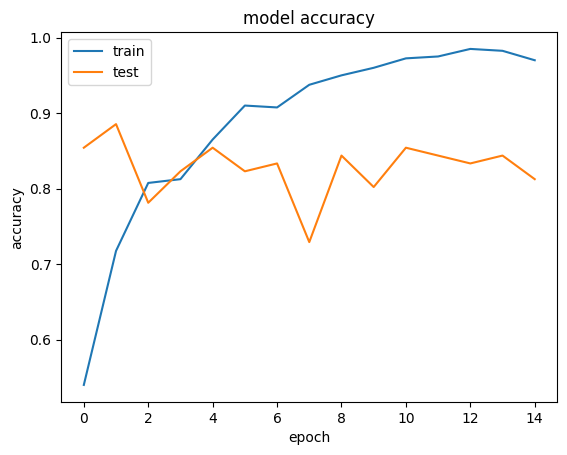

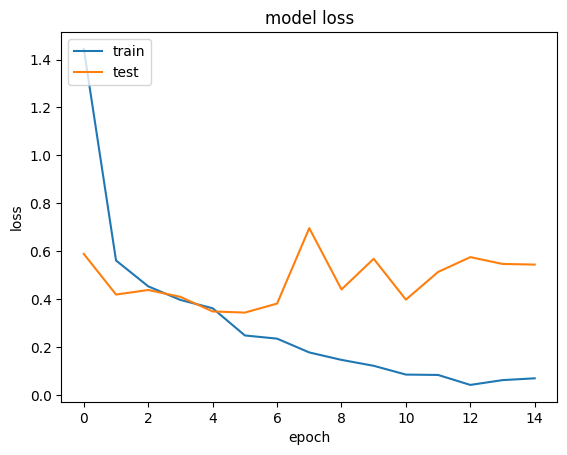

In [28]:
### --- Section visualisation  ---

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()